# EDA: pandas-dev/pandas Statistical Audit

**Research Questions:**
- RQ1: Berapa probabilitas PR berhasil di-merge?
- RQ2: Apakah rata-rata issue mingguan berubah setelah major release?
- RQ3: Berapa probabilitas issue butuh >30 hari untuk ditutup?

**Member:** Tsabita Nuriska R — Data Engineer

## AI Usage Disclosure
**Anggota:** Tsabita Nuriska R – Data Engineer
**Alat yang digunakan:** Claude & Gemini

| Task | Tool | Prompt summary | Output modified |
| :--- | :--- | :--- | :--- |
| Generate API loop | Claude | Ambil data issues & PR pandas | Yes - disesuaikan |
| Pembersihan & pembuatan kolom statistik | Gemini | "Bantu susun ekstraksi data untuk kolom type, is_bug, is_merged, dan duration_days" | Ya - menyelaraskan penamaan variabel dengan kebutuhan analisis kelompok |

**Ditulis sepenuhnya tanpa AI:** Interpretasi EDA dan narasi analisis struktur data awal.

In [ ]:
import requests
import pandas as pd
from datetime import datetime
import time
import json
import os

# 1. Konfigurasi Awal
TOKEN = "MASUKKAN TOKEN"
REPO = "pandas-dev/pandas"
HEADERS = {"Authorization": f"token {TOKEN}"}

# Mengambil data sejak 1 Januari 2025 agar aman dan mencakup major release
BASE_URL = f"https://api.github.com/repos/{REPO}/issues"
params = {
    "state": "all",
    "per_page": 100,
    "since": "2025-01-01T00:00:00Z"
}

raw_data = []
page = 1

print("--- Memulai Proses Penarikan Data dari GitHub API ---")

# 2. Looping Penarikan Data 
while True:
    params["page"] = page
    response = requests.get(BASE_URL, headers=HEADERS, params=params)
    
    # Antisipasi Rate Limit
    if response.status_code == 403:
        print("Terkena Rate Limit! Istirahat dulu 60 detik...")
        time.sleep(60)
        continue
    elif response.status_code != 200:
        print(f"Eror pada halaman {page}: Status {response.status_code}")
        break
        
    data = response.json()
    if not data:
        break
        
    raw_data.extend(data)
    print(f"Berhasil menarik halaman {page}... Total sementara: {len(raw_data)} item")
    page += 1
    time.sleep(0.5) # Jeda tipis biar sopan sama server GitHub

# --- BACKUP DATA MENTAH KE FOLDER RAW ---
os.makedirs("../data/raw", exist_ok=True)
with open("../data/raw/dataset_raw.json", "w") as f:
    json.dump(raw_data, f, indent=4)
print("\n[Audit Trail] Data mentah berhasil di-backup ke 'data/raw/dataset_raw.json'")

# 3. Proses Pembersihan & Pembentukan Kolom Sesuai Kebutuhan Tim
cleaned_records = []

for item in raw_data:
    # Membedakan Issue murni dan Pull Request (PR)
    is_pr = "pull_request" in item
    
    # Mengambil format tanggal
    created_at_str = item["created_at"]
    closed_at_str = item["closed_at"]
    
    created_at = datetime.strptime(created_at_str, "%Y-%m-%dT%H:%M:%SZ") if created_at_str else None
    closed_at = datetime.strptime(closed_at_str, "%Y-%m-%dT%H:%M:%SZ") if closed_at_str else None
    
    # Hitung durasi hari untuk RQ3 (jika sudah ditutup)
    duration_days = (closed_at - created_at).days if (created_at and closed_at) else None
    
    # Cek label 'bug' untuk RQ2
    labels = [label["name"].lower() for label in item.get("labels", [])]
    is_bug = 1 if "bug" in labels else 0
    
    # Cek status merge untuk RQ1 (Khusus PR)
    is_merged = 0
    if is_pr and item.get("pull_request", {}).get("merged_at"):
        is_merged = 1
        
    record = {
        "number": item["number"],
        "type": "pull_request" if is_pr else "issue",
        "is_merged": is_merged,
        "created_at": created_at,
        "closed_at": closed_at,
        "is_bug": is_bug,
        "duration_days": duration_days
    }
    cleaned_records.append(record)

# 4. Simpan ke DataFrame dan Ekspor ke CSV Clean
df_clean = pd.DataFrame(cleaned_records)
os.makedirs("../data/clean", exist_ok=True)
df_clean.to_csv("../data/clean/dataset.csv", index=False)

print("\n--- PROSES SELESAI ---")
print(f"Dataset bersih berhasil disimpan di 'data/clean/dataset.csv' dengan total {len(df_clean)} baris!")

--- Memulai Proses Penarikan Data dari GitHub API ---
Berhasil menarik halaman 1... Total sementara: 100 item
Berhasil menarik halaman 2... Total sementara: 200 item
Berhasil menarik halaman 3... Total sementara: 300 item
Berhasil menarik halaman 4... Total sementara: 400 item
Berhasil menarik halaman 5... Total sementara: 500 item
Berhasil menarik halaman 6... Total sementara: 600 item
Berhasil menarik halaman 7... Total sementara: 700 item
Berhasil menarik halaman 8... Total sementara: 800 item
Berhasil menarik halaman 9... Total sementara: 900 item
Berhasil menarik halaman 10... Total sementara: 1000 item
Berhasil menarik halaman 11... Total sementara: 1100 item
Berhasil menarik halaman 12... Total sementara: 1200 item
Berhasil menarik halaman 13... Total sementara: 1300 item
Berhasil menarik halaman 14... Total sementara: 1400 item
Berhasil menarik halaman 15... Total sementara: 1500 item
Berhasil menarik halaman 16... Total sementara: 1600 item
Berhasil menarik halaman 17... Total

C:\Users\jakbu\AppData\Local\Temp\ipykernel_36740\181387397.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df[df['type'] == 'pull_request'], x='is_merged', palette='Set2')
C:\Users\jakbu\AppData\Local\Temp\ipykernel_36740\181387397.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Rejected/Closed', 'Merged'])


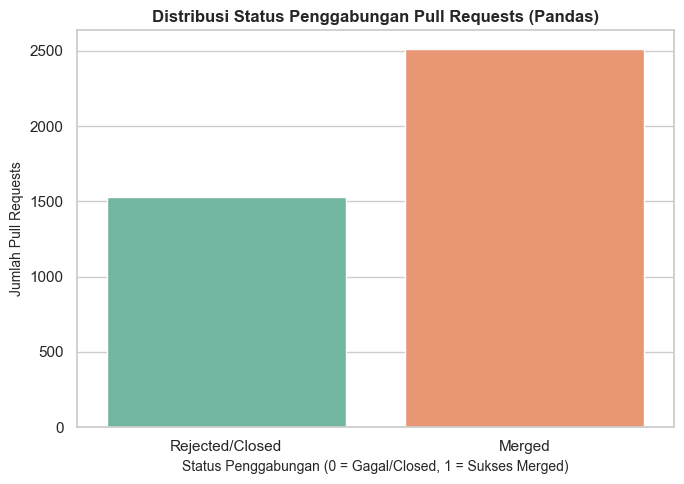

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data bersih yang baru saja berhasil kamu download
df = pd.read_csv("../data/clean/dataset.csv")

# Set tema grafik agar rapi
sns.set_theme(style="whitegrid")

# 2. Buat grafik untuk RQ1 (Proporsi PR yang Berhasil di-merge vs Gagal)
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df[df['type'] == 'pull_request'], x='is_merged', palette='Set2')

# Atur label grafik
plt.title('Distribusi Status Penggabungan Pull Requests (Pandas)', fontsize=12, fontweight='bold')
plt.xlabel('Status Penggabungan (0 = Gagal/Closed, 1 = Sukses Merged)', fontsize=10)
plt.ylabel('Jumlah Pull Requests', fontsize=10)
ax.set_xticklabels(['Rejected/Closed', 'Merged'])

# Munculkan grafik di VS Code
plt.tight_layout()
plt.show()

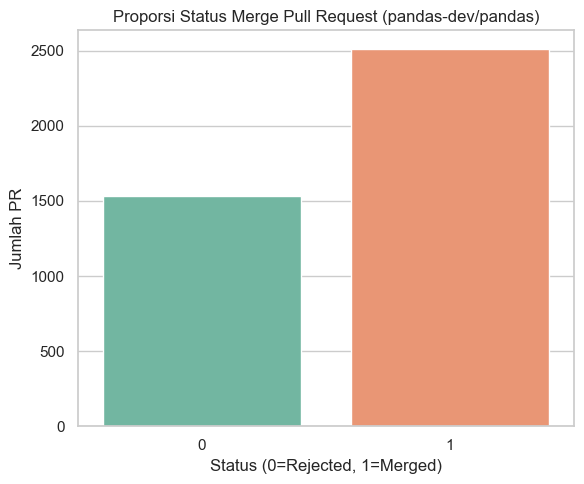

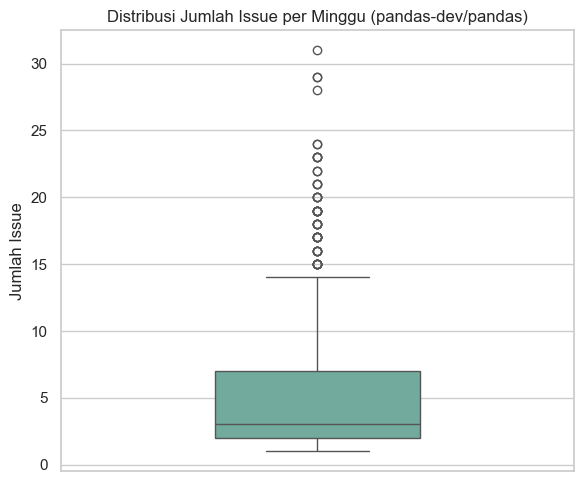

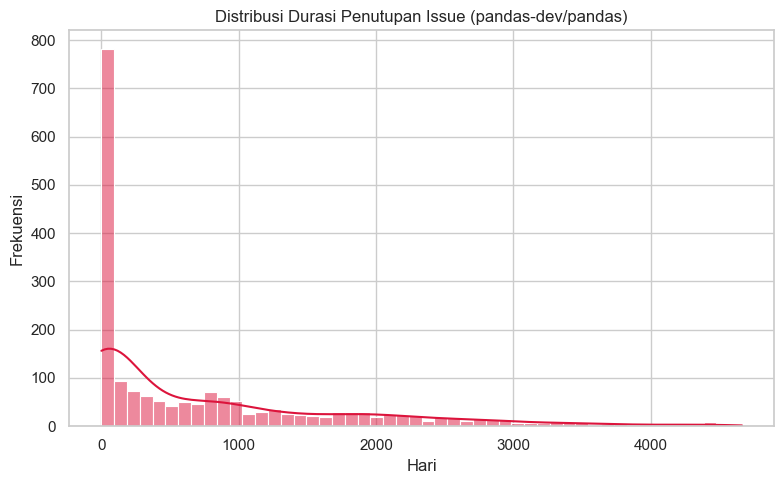

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_csv("../data/clean/dataset.csv")

# Filter
df_pr = df[df['type'] == 'pull_request'].copy()
df_issue = df[df['type'] == 'issue'].copy()
df_issue_clean = df_issue[df_issue['duration_days'] >= 0].copy()

# Q1: Bar chart PR merged vs rejected
plt.figure(figsize=(6, 5))
sns.countplot(data=df_pr, x='is_merged', hue='is_merged', palette='Set2', legend=False)
plt.title('Proporsi Status Merge Pull Request (pandas-dev/pandas)')
plt.xlabel('Status (0=Rejected, 1=Merged)')
plt.ylabel('Jumlah PR')
plt.tight_layout()
plt.show()

# Q2: Boxplot distribusi issue per minggu
df_issue['created_at'] = pd.to_datetime(df_issue['created_at'])
weekly_count = df_issue.groupby(df_issue['created_at'].dt.to_period('W')).size()
plt.figure(figsize=(6, 5))
sns.boxplot(y=weekly_count, color='#69b3a2', width=0.4)
plt.title('Distribusi Jumlah Issue per Minggu (pandas-dev/pandas)')
plt.ylabel('Jumlah Issue')
plt.tight_layout()
plt.show()

# Q3: Histogram durasi penutupan issue
plt.figure(figsize=(8, 5))
sns.histplot(data=df_issue_clean, x='duration_days', bins=50, kde=True, color='crimson')
plt.title('Distribusi Durasi Penutupan Issue (pandas-dev/pandas)')
plt.xlabel('Hari')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

### Analisis

Jika dilihat dari grafik yang sudah dibuat, dapat disimpulkan beberapa hal berikut:
* Jika, dilihat dari grafik yang sudah dibuat. Dapat dilihat bahwa grafik pada bagian merged PR terlihat lebih banyak atau lebih tinggi dibandingkan PR rejected/closed yang dimana PR merged berada pada angka 2.500. Selanjutnya, probabilitas merged memiliki cenderung tinggi dibandingkan PR rejected/close, lalu data hanya diambil dari tahun atau periode tertentu saja